# Detección de datos anómalos con árboles de aislamiento (IForest)

Los bosques de aislamiento (Isolation Forests) son un algoritmo de aprendizaje automático no supervisado diseñado para detectar anomalías o valores atípicos (outliers) en conjuntos de datos.

## ¿Cómo funcionan?

A diferencia de otros métodos de detección de anomalías basados en distancia o densidad (como DBSCAN o LOF), Isolation Forest funciona dividiendo iterativamente los datos en subgrupos hasta que los puntos queden "aislados". Los puntos que se aíslan más rápido (con menos divisiones) son considerados anomalías.

## Pasos clave del algoritmo:

* Construcción del bosque:

Se crean múltiples árboles de aislamiento (isolation trees).
Cada árbol se construye eligiendo una característica aleatoria y dividiendo aleatoriamente el espacio de datos a lo largo de esa característica.

* Medición del nivel de aislamiento:

Si un punto se aísla en pocas divisiones, se considera más anómalo.
Si un punto requiere muchas divisiones para quedar aislado, es más probable que sea un dato normal.
Cálculo del puntaje de anomalía:

Se usa la profundidad media en la que un punto es aislado dentro del bosque.
Un puntaje alto indica que el punto es un valor atípico.


## Ejemplo visual simple

En el siguiente ejemplo vemos claramente que los valores que se aíslan más rápidamente que otros, independientemente del nivel exacto en el que esto ocurre son el 1 y el 10.

![Arbol de aislamiento](./img/iforest1.png)

![Arbol de aislamiento](./img/iforest2.png)

## Ejemplo en Python

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [4]:
carros = np.loadtxt("../datos/carros_usados.csv", delimiter=",")
resultados = np.zeros((3, carros.size//2))

carros.shape, resultados.shape

((78, 2), (3, 78))

In [7]:
# Bosques de aislamiento con diferente contaminacion
# La contaminacion indica el nivel de datos anomalos que supuestamente tienen nuestros datos, ej 0.05 (5%), etc
c = [0.01, 0.05, 0.10]

for i in range(len(c)):
    modelo = IsolationForest(contamination=c[i]).fit(carros)
    resultados[i] = modelo.predict(carros) # usamos los mismos datos de entrenamiento en este caso solo para fines didacticos

# Cada prediccion nos devolverá 1 para dato normal, -1 para dato anómalo
resultados 

array([[ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,  1.,
         1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,  1., -1.],
       [-1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  

<Figure size 640x480 with 0 Axes>

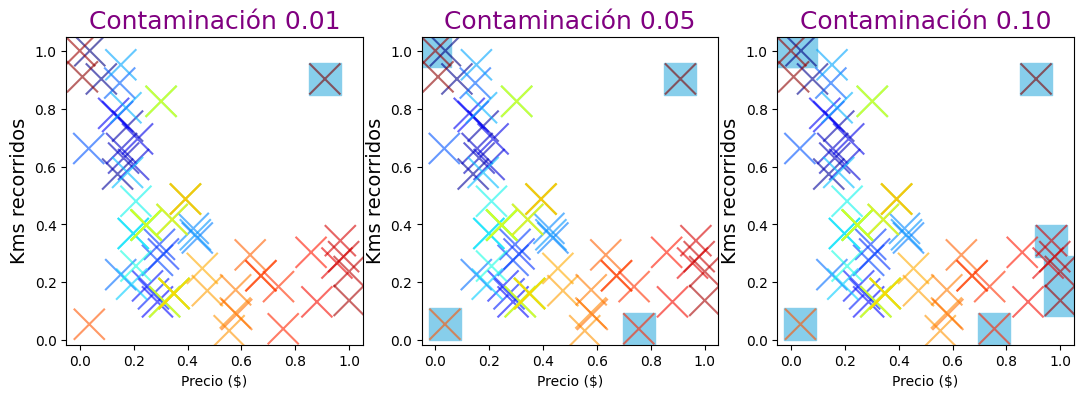

In [10]:
# Graficar datos anomalos
plt.set_cmap("jet")
fig = plt.figure(figsize=(13, 4))

for i in range(len(c)):
    ax = fig.add_subplot(1, 3, i+1)
    ax.scatter(carros[resultados[i] == -1][:, 0], 
               carros[resultados[i] == -1][:, 1],
               c="skyblue", marker="s", s=500)
    ax.scatter(carros[:, 0], 
               carros[:, 1],
               c=range(carros.size//2), marker="x", s=500, alpha=0.6)
    ax.set_title("Contaminación %0.2f" % c[i], size=18, color="purple")
    ax.set_xlabel("Precio ($)", size=10)
    ax.set_ylabel("Kms recorridos", size=14)

plt.show()

In [11]:
carros[resultados[1] == -1]

array([[0.0355, 0.0552],
       [0.7553, 0.0395],
       [0.    , 0.9999],
       [0.9099, 0.9025]])